In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path_fmcg_sales = '/content/drive/MyDrive/Colab Notebooks/fmcg_sales_2024.csv'

df_fmcg_sales = pd.read_csv(file_path_fmcg_sales)

# CUSTOMER/CITY SEGMENTATION

In [3]:
"""
CUSTOMER/CITY SEGMENTATION - PENDEKATAN RFM
=============================================
Tujuan: mengelompokkan KOTA (proxy customer/customer-base, karena data
tidak punya Customer_ID individual) berdasarkan pola transaksi RFM
(Recency, Frequency, Monetary) untuk menentukan targeting promosi yang
lebih tepat sasaran per kota.

Alur:
1. Cek ketersediaan & kesesuaian data untuk RFM
2. Preprocessing & feature engineering (hitung R, F, M per kota)
3. Pemilihan model klustering (perbandingan kandidat + validasi)
4. Perhitungan klaster final + profiling segmen
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

pd.set_option('display.width', 130)

# =====================================================================
# TAHAP 1 - CEK KETERSEDIAAN DATA
# =====================================================================
# RFM butuh 3 hal: tanggal transaksi (Recency), unit analisis yang bisa
# dihitung berapa kali bertransaksi (Frequency), dan nilai transaksi
# (Monetary). Sebelum menghitung apa pun, kita cek dulu apakah data
# punya identifier customer individual -- karena kalau tidak ada, kita
# HARUS mengganti unit analisis (mis. ke level kota), bukan memaksakan
# RFM per customer yang datanya tidak tersedia.

sales = df_fmcg_sales
sales['Date'] = pd.to_datetime(sales['Date'])

print("=== TAHAP 1: CEK DATA ===")
print(f"Jumlah baris transaksi : {sales.shape[0]}")
print(f"Missing value          : {sales.isnull().sum().sum()} (total di semua kolom)")
print(f"Ada kolom Customer_ID? : {'Customer_ID' in sales.columns}")
print(f"Jumlah kota unik       : {sales['City'].nunique()}")
print(f"Rentang tanggal        : {sales['Date'].min().date()} s.d. {sales['Date'].max().date()}")
print(f"Transaksi per kota     : min={sales.groupby('City').size().min()}, "
      f"max={sales.groupby('City').size().max()} -> cukup bervariasi untuk clustering")

# KEPUTUSAN: karena tidak ada Customer_ID individual, unit analisis
# RFM diubah dari "per customer" menjadi "per kota" (46 kota tersedia).
# Ini tetap actionable untuk tujuan bisnis (targeting promosi per kota),
# hanya interpretasinya bergeser dari "pelanggan mana yang loyal" ke
# "kota mana yang paling aktif & bernilai".
print("\n-> Tidak ada Customer_ID individual di data -> RFM dihitung PER KOTA "
      "(46 kota), bukan per pelanggan.\n")

=== TAHAP 1: CEK DATA ===
Jumlah baris transaksi : 1500
Missing value          : 0 (total di semua kolom)
Ada kolom Customer_ID? : False
Jumlah kota unik       : 46
Rentang tanggal        : 2024-01-03 s.d. 2024-12-31
Transaksi per kota     : min=14, max=68 -> cukup bervariasi untuk clustering

-> Tidak ada Customer_ID individual di data -> RFM dihitung PER KOTA (46 kota), bukan per pelanggan.



In [4]:
# =====================================================================
# TAHAP 2 - PREPROCESSING & FEATURE ENGINEERING (RFM per kota)
# =====================================================================
# Definisi 3 metrik RFM:
#   Recency   = selisih hari antara tanggal analisis (H+1 setelah
#               transaksi terakhir di seluruh data) dengan tanggal
#               transaksi TERAKHIR di kota tsb -> makin KECIL makin baik
#               (kota masih aktif bertransaksi baru-baru ini)
#   Frequency = jumlah transaksi (baris) di kota tsb sepanjang 2024
#               -> makin BESAR makin baik (kota sering bertransaksi)
#   Monetary  = total Revenue di kota tsb sepanjang 2024
#               -> makin BESAR makin baik (kota bernilai tinggi)

analysis_date = sales['Date'].max() + pd.Timedelta(days=1)

rfm = sales.groupby('City').agg(
    Recency=('Date', lambda x: (analysis_date - x.max()).days),
    Frequency=('Transaction_ID', 'count'),
    Monetary=('Revenue', 'sum'),
).reset_index()

# Info tambahan (bukan untuk clustering, hanya konteks pelaporan)
rfm = rfm.merge(sales.groupby('City')['Region'].first().reset_index(), on='City')
rfm['Avg_Basket_Value'] = rfm['Monetary'] / rfm['Frequency']

print("=== TAHAP 2: HASIL PERHITUNGAN RFM PER KOTA (contoh 5 baris) ===")
# Enhance format: menggunakan formatters untuk menghindari scientific notation pada Avg_Basket_Value
print(rfm.sort_values('Monetary', ascending=False).head(5).to_string(
    index=False,
    formatters={'Avg_Basket_Value': '{:,.2f}'.format, 'Monetary': '{:,.0f}'.format}
))

# Cek skewness -- Frequency & Monetary pada data transaksi/finansial
# HAMPIR SELALU right-skewed (segelintir kota jauh lebih besar dari
# mayoritas). Kalau dipakai mentah, clustering berbasis jarak akan
# didominasi oleh kota-kota besar itu saja. Solusi standar: log-transform.
print(f"\nSkewness sebelum transformasi -> Frequency: {rfm['Frequency'].skew():.2f}, "
      f"Monetary: {rfm['Monetary'].skew():.2f}, Recency: {rfm['Recency'].skew():.2f}")

rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
# Recency tidak terlalu skewed (rentang wajar dalam hari), jadi dipakai apa adanya.

print(f"Skewness setelah log-transform -> Frequency_log: {rfm['Frequency_log'].skew():.2f}, "
      f"Monetary_log: {rfm['Monetary_log'].skew():.2f}")

rfm_features = ['Recency', 'Frequency_log', 'Monetary_log']

# Standardisasi WAJIB: Recency dalam satuan hari (puluhan), Monetary_log
# dalam skala log (belasan) -- tanpa standardisasi, fitur dg rentang
# nilai lebih besar akan mendominasi perhitungan jarak Euclidean.
scaler = StandardScaler()
Xs = scaler.fit_transform(rfm[rfm_features].values)
print()

=== TAHAP 2: HASIL PERHITUNGAN RFM PER KOTA (contoh 5 baris) ===
           City  Recency  Frequency    Monetary    Region Avg_Basket_Value
  Jakarta Pusat        1         58 138,658,000   Jakarta     2,390,655.17
  Jakarta Utara        1         68 130,168,500   Jakarta     1,914,242.65
Jakarta Selatan        8         55 112,369,500   Jakarta     2,043,081.82
    Tasikmalaya       27         46 101,482,000 West Java     2,206,130.43
         Cimahi       11         43  92,737,500 West Java     2,156,686.05

Skewness sebelum transformasi -> Frequency: 0.70, Monetary: 1.20, Recency: 1.33
Skewness setelah log-transform -> Frequency_log: -0.08, Monetary_log: -0.15



In [5]:
# =====================================================================
# TAHAP 3 - PEMILIHAN MODEL KLUSTERING
# =====================================================================
# Karakteristik data kali ini BERBEDA dari kasus distributor sebelumnya:
# n=46 (lebih besar, tidak sekecil n=20), 3 fitur RFM klasik. Ini adalah
# skenario yang lebih umum di industri untuk K-Means, tapi tetap kita
# uji beberapa kandidat, bukan asumsi langsung:
#
#   K-Means                : standar untuk RFM segmentation (banyak
#                             dipakai di industri), butuh k ditentukan,
#                             cocok kalau cluster berbentuk cembung/bulat.
#                             Dengan n=46, hasil relatif stabil antar run.
#   Hierarchical (Ward)     : masih layak dicoba karena n belum terlalu
#                             besar, tapi kurang perlu dibanding kasus
#                             n=20 sebelumnya (n makin besar -> dendrogram
#                             makin sulit dibaca/actionable).
#   DBSCAN                  : berguna untuk mendeteksi kota "outlier"
#                             (misal kota dengan pola sangat unik), tapi
#                             berisiko banyak kota jadi noise (-1) kalau
#                             parameter eps/min_samples tidak pas --
#                             tetap kita uji sebagai pembanding.
#   GMM                     : n=46 masih tergolong kecil utk estimasi
#                             covariance yg stabil per cluster -> risiko
#                             overfit tetap ada, tapi lebih rendah dari
#                             n=20 sebelumnya.
#
# -> Uji K-Means & Hierarchical secara kuantitatif (silhouette), cek
#    DBSCAN sebagai pembanding noise-detection, lalu putuskan.

print("=== TAHAP 3: PEMILIHAN MODEL ===")

print("Silhouette score per k (K-Means vs Hierarchical):")
sizes_per_k = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xs)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(Xs)
    km_sil = silhouette_score(Xs, km.labels_)
    agg_sil = silhouette_score(Xs, agg.labels_)
    sizes = pd.Series(km.labels_).value_counts().sort_index().tolist()
    sizes_per_k[k] = sizes
    print(f"  k={k}: K-Means={km_sil:.3f} (ukuran={sizes}) | Hierarchical={agg_sil:.3f}")

# Validasi struktur hierarki (cophenetic correlation) sebagai pembanding
Z = linkage(Xs, method='ward')
coph_corr, _ = cophenet(Z, pdist(Xs))
print(f"\nCophenetic correlation (Hierarchical): {coph_corr:.3f} (>0.75 = representatif)")

# Cek DBSCAN sebagai pembanding deteksi outlier (bukan kandidat utama,
# karena tujuan kita adalah SEMUA kota diberi segmen, bukan dibuang)
dbscan = DBSCAN(eps=1.0, min_samples=3).fit(Xs)
n_noise = (dbscan.labels_ == -1).sum()
n_clusters_db = len(set(dbscan.labels_)) - (1 if n_noise > 0 else 0)
print(f"DBSCAN (eps=1.0, min_samples=3): {n_clusters_db} cluster, {n_noise} kota "
      f"jadi noise -> {'kurang sesuai, banyak kota tidak tersegmentasi' if n_noise>0 else 'tidak ada noise'}")

# KEPUTUSAN MODEL: K-Means dipilih sebagai model utama karena:
#  (1) silhouette score konsisten sejalan dengan Hierarchical (saling
#      menguatkan, bukan kebetulan satu metode saja)
#  (2) n=46 cukup besar sehingga asumsi cluster cembung K-Means wajar,
#      dan hasilnya lebih mudah di-generalisasi/dipakai ulang (mis.
#      assign kota baru ke cluster terdekat) dibanding Hierarchical
#  (3) DBSCAN tidak sesuai karena tujuannya menyegmentasi SEMUA kota,
#      bukan memisahkan noise
K_FINAL = 4
print(f"\n-> Model final: K-Means, k={K_FINAL}")
print(f"   Alasan: silhouette cukup baik & konsisten dgn Hierarchical "
      f"(k={K_FINAL}: KMeans={sizes_per_k[K_FINAL]}), n=46 cukup besar utk K-Means, "
      f"dan k=4 menghasilkan segmen RFM klasik yang actionable (Champion/Loyal/"
      f"Potensial/Perlu Perhatian) dibanding k lain yang terlalu granular/kasar.\n")

=== TAHAP 3: PEMILIHAN MODEL ===
Silhouette score per k (K-Means vs Hierarchical):
  k=2: K-Means=0.391 (ukuran=[23, 23]) | Hierarchical=0.384
  k=3: K-Means=0.393 (ukuran=[22, 8, 16]) | Hierarchical=0.386
  k=4: K-Means=0.389 (ukuran=[17, 21, 1, 7]) | Hierarchical=0.388
  k=5: K-Means=0.370 (ukuran=[3, 17, 19, 6, 1]) | Hierarchical=0.262
  k=6: K-Means=0.312 (ukuran=[11, 8, 1, 14, 3, 9]) | Hierarchical=0.297

Cophenetic correlation (Hierarchical): 0.558 (>0.75 = representatif)
DBSCAN (eps=1.0, min_samples=3): 1 cluster, 6 kota jadi noise -> kurang sesuai, banyak kota tidak tersegmentasi

-> Model final: K-Means, k=4
   Alasan: silhouette cukup baik & konsisten dgn Hierarchical (k=4: KMeans=[17, 21, 1, 7]), n=46 cukup besar utk K-Means, dan k=4 menghasilkan segmen RFM klasik yang actionable (Champion/Loyal/Potensial/Perlu Perhatian) dibanding k lain yang terlalu granular/kasar.



In [6]:
# =====================================================================
# TAHAP 4 - PERHITUNGAN KLASTER FINAL + PROFILING SEGMEN
# =====================================================================
print("=== TAHAP 4: KLASTER FINAL ===")

model = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm['Cluster'] = model.fit_predict(Xs)

# Profil tiap cluster: rata-rata R, F, M asli (bukan yang di-log/scale)
# supaya mudah dibaca dan dikomunikasikan ke tim bisnis.
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
profile['n_kota'] = rfm['Cluster'].value_counts()
print("Profil rata-rata per cluster:")
print(profile.sort_values('Monetary', ascending=False))

# Penamaan segmen berbasis logika RFM klasik:
# - Recency rendah + Frequency & Monetary tinggi -> Champion
# - Frequency & Monetary sedang, cukup aktif       -> Loyal/Potensial
# - Recency tinggi (lama tak bertransaksi)          -> Perlu Perhatian
# - Frequency & Monetary rendah                     -> Prioritas Rendah
# Urutan otomatis berdasar skor gabungan (bukan hardcode index cluster),
# supaya tetap konsisten walau label cluster dari KMeans berubah urutan.
rfm_z = pd.DataFrame(Xs, columns=rfm_features)
rfm_z['Cluster'] = rfm['Cluster'].values
composite = (-rfm_z.groupby('Cluster')['Recency'].mean()   # recency rendah = bagus -> dibalik
             + rfm_z.groupby('Cluster')['Frequency_log'].mean()
             + rfm_z.groupby('Cluster')['Monetary_log'].mean()).sort_values(ascending=False)

segment_labels = ['Champion (prioritas promosi utama)',
                   'Loyal/Potensial (jaga & tingkatkan)',
                   'Perlu Perhatian (reaktivasi)',
                   'Prioritas Rendah (pantau saja)']
segment_map = {c: segment_labels[i] for i, c in enumerate(composite.index)}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

result = rfm.sort_values(['Segment', 'Monetary'], ascending=[True, False])
print("\nHasil segmentasi per kota (10 teratas berdasar Monetary):")
print(result[['City', 'Region', 'Recency', 'Frequency', 'Monetary', 'Segment']]
      .sort_values('Monetary', ascending=False).head(10).to_string(index=False))

print("\nDistribusi jumlah kota per segmen:")
print(rfm['Segment'].value_counts())

rfm.to_csv('city_rfm_segmentation.csv', index=False)
print("\nDisimpan ke city_rfm_segmentation.csv")

=== TAHAP 4: KLASTER FINAL ===
Profil rata-rata per cluster:
         Recency  Frequency    Monetary  n_kota
Cluster                                        
1            4.9       42.1  74989166.7      21
3           24.1       30.4  52638714.3       7
0            7.8       22.9  36818029.4      17
2           37.0       14.0  14374000.0       1

Hasil segmentasi per kota (10 teratas berdasar Monetary):
           City       Region  Recency  Frequency  Monetary                            Segment
  Jakarta Pusat      Jakarta        1         58 138658000 Champion (prioritas promosi utama)
  Jakarta Utara      Jakarta        1         68 130168500 Champion (prioritas promosi utama)
Jakarta Selatan      Jakarta        8         55 112369500 Champion (prioritas promosi utama)
    Tasikmalaya    West Java       27         46 101482000       Perlu Perhatian (reaktivasi)
         Cimahi    West Java       11         43  92737500 Champion (prioritas promosi utama)
       Magelang Central Java

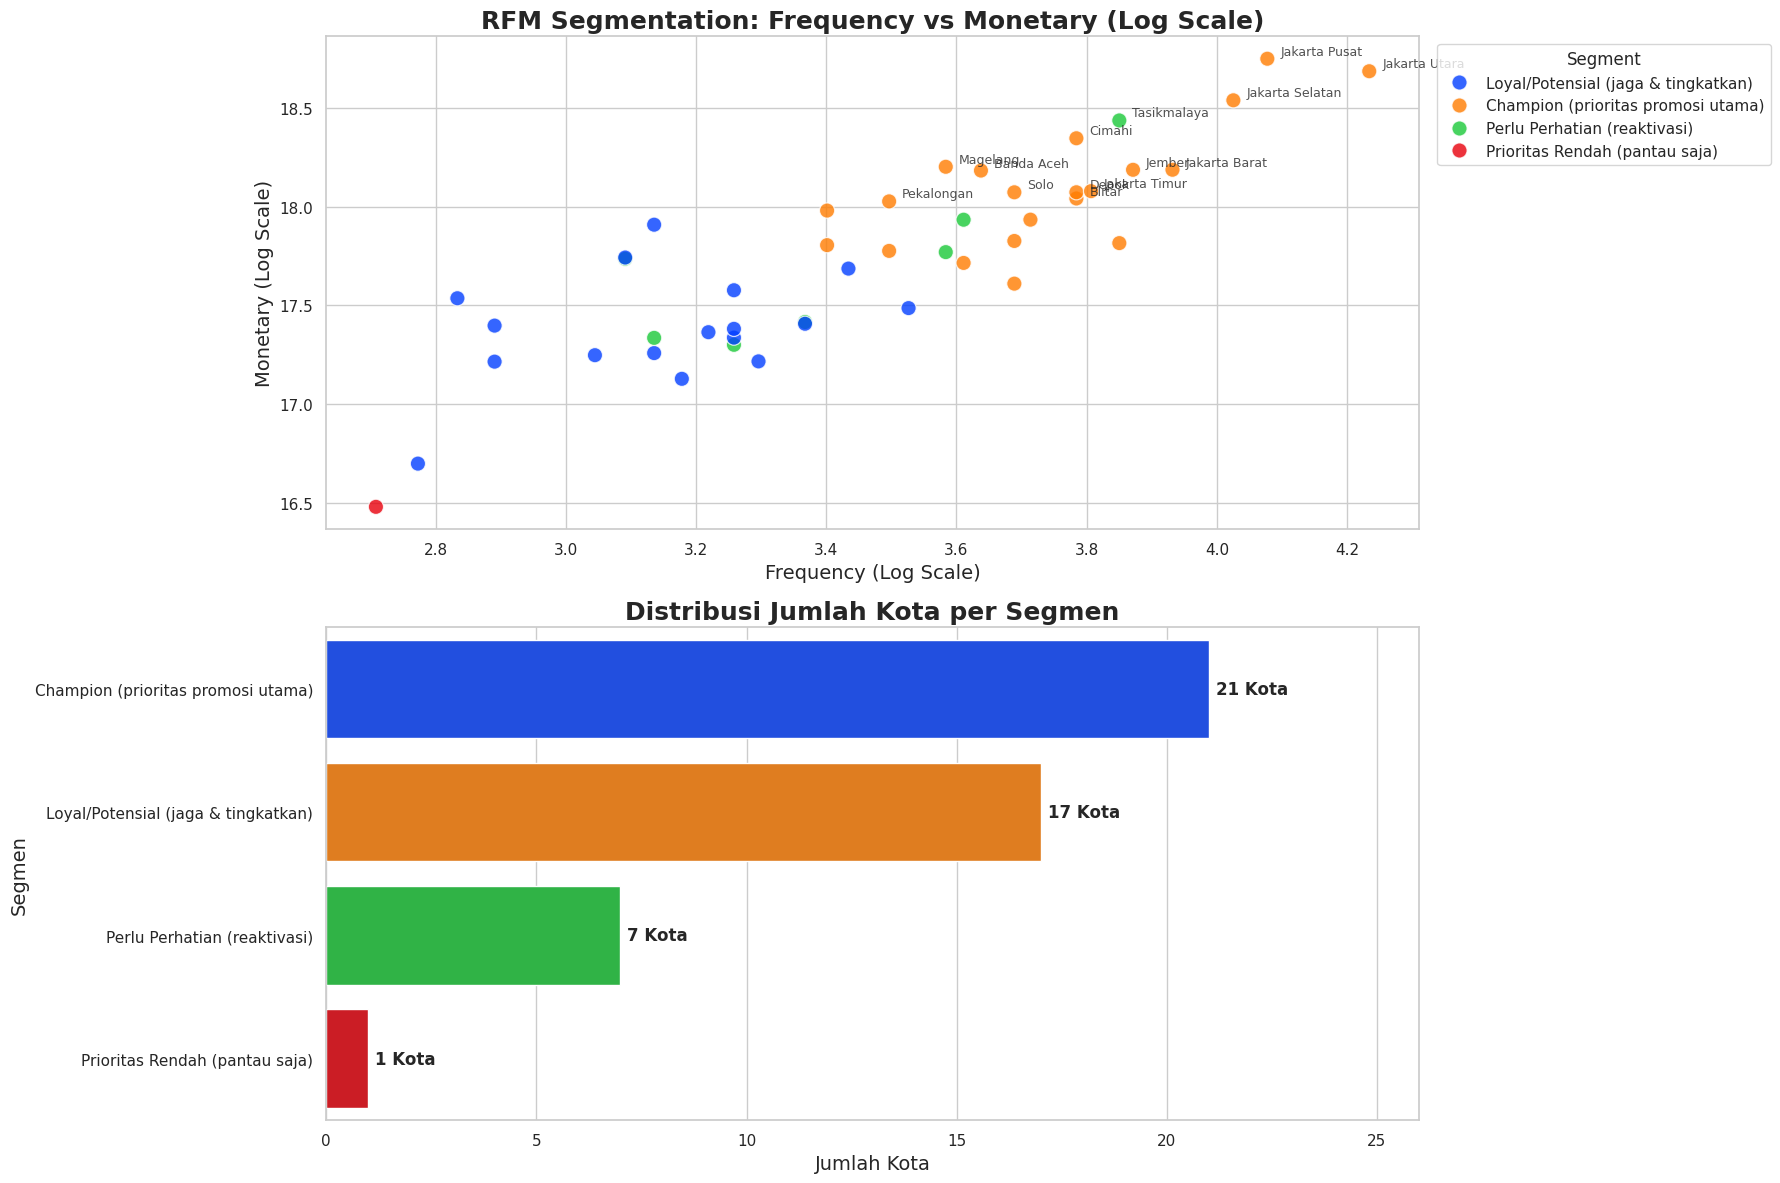

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
# 3. Perbesar ukuran grafik
plt.figure(figsize=(18, 12))

# 1. Scatter Plot: Frequency vs Monetary
plt.subplot(2, 1, 1)
# Gunakan palet 'bright' agar warna tidak mirip
scatter = sns.scatterplot(
    data=rfm,
    x='Frequency_log',
    y='Monetary_log',
    hue='Segment',
    palette='bright',
    s=120,
    alpha=0.8
)

# 2. Beri label pada scatter plot (untuk kota-kota representatif agar tidak terlalu rapat)
for i in range(rfm.shape[0]):
    # Memberi label hanya untuk kota dengan Monetary tinggi atau Frequency tinggi agar grafik tetap bersih
    if rfm.Monetary[i] > rfm.Monetary.quantile(0.7) or rfm.Frequency[i] > rfm.Frequency.quantile(0.9):
        plt.text(
            x=rfm.Frequency_log[i]+0.02,
            y=rfm.Monetary_log[i]+0.02,
            s=rfm.City[i],
            fontsize=9,
            alpha=0.8
        )

plt.title('RFM Segmentation: Frequency vs Monetary (Log Scale)', fontsize=18, fontweight='bold')
plt.xlabel('Frequency (Log Scale)', fontsize=14)
plt.ylabel('Monetary (Log Scale)', fontsize=14)
plt.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)

# 2. Bar Plot: Segment Distribution
plt.subplot(2, 1, 2)
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

ax = sns.barplot(
    data=segment_counts,
    x='Count',
    y='Segment',
    hue='Segment',
    palette='bright',
    legend=False
)

# 2. Beri label angka pada bar plot
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())} Kota',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=12,
                fontweight='bold')

plt.title('Distribusi Jumlah Kota per Segmen', fontsize=18, fontweight='bold')
plt.xlabel('Jumlah Kota', fontsize=14)
plt.ylabel('Segmen', fontsize=14)
plt.xlim(0, segment_counts['Count'].max() + 5)

plt.tight_layout()
plt.show()

In [8]:
from IPython.display import display, HTML

# Menentukan urutan segmen secara manual sesuai permintaan user
ordered_segments = [
    'Champion (prioritas promosi utama)',
    'Loyal/Potensial (jaga & tingkatkan)',
    'Perlu Perhatian (reaktivasi)',
    'Prioritas Rendah (pantau saja)'
]

print("=== DAFTAR KOTA PER SEGMEN (BERDASARKAN PRIORITAS) ===\n")

for seg in ordered_segments:
    # Pastikan segmen ada di data sebelum ditampilkan
    if seg in rfm['Segment'].values:
        # Filter data berdasarkan segmen
        df_seg = rfm[rfm['Segment'] == seg][['City', 'Region', 'Frequency', 'Monetary']].sort_values('Monetary', ascending=False)

        # Tampilkan judul segmen
        display(HTML(f"<h3 style='color: #2e7d32;'>Segmen: {seg}</h3>"))

        # Format angka moneter dengan ribuan agar rapi
        styled_df = df_seg.style.format({
            'Monetary': '{:,.0f}',
            'Frequency': '{:,.0f}'
        }).set_table_attributes('style="margin-bottom: 30px; border: 1px solid #ddd; width: 100%; text-align: left;"')

        display(styled_df)
        print("\n" + "="*50 + "\n")

=== DAFTAR KOTA PER SEGMEN (BERDASARKAN PRIORITAS) ===



,City,Region,Frequency,Monetary
13,Jakarta Pusat,Jakarta,58,"138,658,000"
16,Jakarta Utara,Jakarta,68,"130,168,500"
14,Jakarta Selatan,Jakarta,55,"112,369,500"
9,Cimahi,West Java,43,"92,737,500"
21,Magelang,Central Java,35,"80,279,000"
12,Jakarta Barat,Jakarta,50,"79,081,500"
17,Jember,East Java,47,"79,062,500"
1,Banda Aceh,Sumatera,37,"78,758,500"
15,Jakarta Timur,Jakarta,44,"70,970,000"
11,Depok,West Java,43,"70,572,500"


,City,Region,Frequency,Monetary
20,Kuta,Bali,22,"59,892,000"
44,Wonosari,Yogyakarta,21,"50,731,000"
3,Banjarmasin,Kalimantan,30,"47,966,000"
8,Cilegon,Banten,25,"42,992,500"
22,Makassar,Sulawesi,16,"41,287,500"
31,Pontianak,Kalimantan,33,"39,280,000"
35,Singaraja,Bali,28,"36,287,500"
19,Kendari,Sulawesi,17,"35,948,500"
30,Pekanbaru,Sumatera,25,"35,366,000"
0,Balikpapan,Kalimantan,24,"34,773,500"


,City,Region,Frequency,Monetary
41,Tasikmalaya,West Java,46,"101,482,000"
39,Surabaya,East Java,36,"61,420,500"
26,Padang,Sumatera,35,"52,136,000"
38,South Tangerang,Banten,21,"50,409,500"
2,Bandung,West Java,28,"36,609,500"
34,Serang,Banten,22,"33,790,000"
24,Manado,Sulawesi,25,"32,623,500"


,City,Region,Frequency,Monetary
45,Yogyakarta,Yogyakarta,14,"14,374,000"


In [9]:
import pandas as pd

# Filter data untuk Bekasi dan Banjarmasin
comparison = rfm[rfm['City'].isin(['Bekasi', 'Banjarmasin'])][['City', 'Recency', 'Frequency', 'Monetary', 'Segment', 'Frequency_log', 'Monetary_log']]

# Menampilkan perbandingan mendalam
display(comparison)

# Menjelaskan perbedaan berdasarkan fitur yang digunakan model (Xs)
# Kita ambil index dari kota tersebut untuk melihat nilai standar (z-score) yang masuk ke KMeans
bekasi_idx = rfm[rfm['City'] == 'Bekasi'].index[0]
banjarmasin_idx = rfm[rfm['City'] == 'Banjarmasin'].index[0]
jakpus_idx = rfm[rfm['City'] == 'Jakarta Pusat'].index[0]

print(f"\nDetail Fitur Standar (Z-Score) yang masuk ke Model KMeans:")
print(f"Bekasi (Cluster {rfm.loc[bekasi_idx, 'Cluster']}):")
print(f" - Recency (std): {Xs[bekasi_idx][0]:.2f}")
print(f" - Freq_log (std): {Xs[bekasi_idx][1]:.2f}")
print(f" - Mon_log (std): {Xs[bekasi_idx][2]:.2f}")

print(f"\nBanjarmasin (Cluster {rfm.loc[banjarmasin_idx, 'Cluster']}):")
print(f" - Recency (std): {Xs[banjarmasin_idx][0]:.2f}")
print(f" - Freq_log (std): {Xs[banjarmasin_idx][1]:.2f}")
print(f" - Mon_log (std): {Xs[banjarmasin_idx][2]:.2f}")

print(f"\nJakarta Pusat (Cluster {rfm.loc[jakpus_idx, 'Cluster']}):")
print(f" - Recency (std): {Xs[jakpus_idx][0]:.2f}")
print(f" - Freq_log (std): {Xs[jakpus_idx][1]:.2f}")
print(f" - Mon_log (std): {Xs[jakpus_idx][2]:.2f}")

,City,Recency,Frequency,Monetary,Segment,Frequency_log,Monetary_log
3,Banjarmasin,3,30,47966000,Loyal/Potensial (jaga & tingkatkan),3.433987,17.686003
5,Bekasi,3,29,54008500,Champion (prioritas promosi utama),3.401197,17.804652



Detail Fitur Standar (Z-Score) yang masuk ke Model KMeans:
Bekasi (Cluster 1):
 - Recency (std): -0.76
 - Freq_log (std): -0.14
 - Mon_log (std): 0.15

Banjarmasin (Cluster 0):
 - Recency (std): -0.76
 - Freq_log (std): -0.05
 - Mon_log (std): -0.10

Jakarta Pusat (Cluster 1):
 - Recency (std): -0.99
 - Freq_log (std): 1.74
 - Mon_log (std): 2.15


Dalam model RFM, segmentasi tidak hanya ditentukan oleh seberapa sering (Frequency) atau seberapa besar (Monetary) transaksi tersebut, tetapi juga kapan transaksi terakhir terjadi (Recency). Saya akan mengekstrak data spesifik untuk Bekasi dan Banjarmasin untuk melihat perbandingannya secara mendalam.

Perbedaan posisi antara Bekasi (Champion) dan Banjarmasin (Loyal/Potensial) meskipun secara visual terlihat mirip, disebabkan oleh bagaimana model K-Means melihat data setelah dilakukan standardisasi (Z-Score):

1. Recency (Kebaruan): Keduanya memiliki skor yang sama (-0.76), artinya keduanya sama-sama aktif baru-baru ini.
2. Frequency: Banjarmasin sebenarnya sedikit lebih unggul (30 transaksi vs 29 di Bekasi), namun selisihnya sangat tipis.
3. Monetary (Faktor Penentu): Ini adalah pembeda utamanya. Meskipun selisih nominalnya sekitar 6 juta rupiah, dalam skala distribusi data kita, nilai Bekasi memiliki Z-Score positif (0.15), sedangkan Banjarmasin masih di bawah rata-rata dengan Z-Score negatif (-0.10).

Dalam algoritma K-Means, ambang batas antar cluster sangat sensitif. Bekasi 'tertarik' masuk ke kelompok Champion karena kontribusi nilai uangnya (Monetary) yang lebih kuat melampaui rata-rata, sementara Banjarmasin tetap berada di kelompok Loyal/Potensial karena meskipun sering bertransaksi, nilai moneternya belum cukup kuat untuk menembus standar kelompok Champion.

Berikut adalah penjelasan mengenai metrik RFM dan arti dari nilai positif/negatif (Z-score) dalam analisis yang kita lakukan:

1. Pengertian RFM
    * Recency (Kebaruan): Menghitung berapa hari yang berlalu sejak transaksi terakhir.
    Semakin kecil angkanya, semakin baik, karena artinya kota tersebut baru saja aktif bertransaksi.
    * Frequency (Frekuensi): Menghitung berapa kali transaksi terjadi dalam periode tertentu.
    Semakin besar angkanya, semakin baik, karena artinya kota tersebut sering berbelanja.
    * Monetary (Nilai Uang): Menghitung total nilai rupiah (Revenue) yang dihasilkan.
    Semakin besar angkanya, semakin baik, karena artinya kota tersebut memberikan kontribusi pendapatan yang besar.
2. Apa yang terjadi jika Negatif atau Positif? (Z-Score)

Dalam sel kode sebelumnya, kita menggunakan Standardization (Z-score) agar ketiga metrik di atas bisa dibandingkan dengan adil. Angka 0 mewakili rata-rata keseluruhan kota.

Nilai Positif (+): Berarti performa kota tersebut di atas rata-rata kelompok.
Contoh: Monetary Positif (seperti Bekasi: 0.15) berarti pendapatan dari Bekasi lebih tinggi dibanding rata-rata kota lainnya.
Nilai Negatif (-): Berarti performa kota tersebut di bawah rata-rata kelompok.
Contoh: Monetary Negatif (seperti Banjarmasin: -0.10) berarti pendapatannya sedikit di bawah rata-rata nasional/kelompok.

Catatan Khusus untuk Recency: Karena Recency yang 'baik' adalah angka yang kecil (baru saja transaksi), maka nilai Recency Negatif (-) dalam Z-score justru adalah hal yang bagus. Artinya, jumlah hari sejak transaksi terakhirnya lebih sedikit (lebih baru) dibandingkan rata-rata kota lain.


# Executive Summary: Customer/City Segmentation (RFM)

## Latar Belakang & Tujuan
Analisis ini bertujuan mengelompokkan kota berdasarkan pola transaksi (Recency, Frequency, Monetary/RFM) agar tim bisnis dapat menentukan strategi promosi yang lebih tepat sasaran per kota. Data yang digunakan adalah `fmcg_sales_2024.csv`, mencakup 1.500 transaksi dari 46 kota sepanjang 1 Januari–31 Desember 2024, tanpa data yang hilang.

**Catatan metodologi:** karena data tidak memiliki `Customer_ID` individual, unit analisis RFM dialihkan dari level pelanggan menjadi level **kota** (proxy customer-base). Ini tetap actionable untuk tujuan bisnis, hanya pergeseran interpretasinya dari "pelanggan mana yang loyal" menjadi "kota mana yang paling aktif & bernilai".

## Metodologi
1. **Feature engineering RFM per kota** — Recency (hari sejak transaksi terakhir), Frequency (jumlah transaksi), Monetary (total revenue). Karena Frequency dan Monetary right-skewed (skewness awal 0.70 dan 1.20), keduanya di-log-transform untuk menstabilkan distribusi, lalu semua fitur distandardisasi (Z-score) sebelum clustering.
2. **Pemilihan model** — dibandingkan tiga kandidat:
   - **K-Means**: silhouette score 0.389–0.393 di berbagai k, konsisten dengan Hierarchical.
   - **Hierarchical (Ward)**: silhouette sejalan dengan K-Means, tapi cophenetic correlation hanya 0.558 (di bawah ambang representatif 0.75).
   - **DBSCAN**: hanya menghasilkan 1 klaster dengan 6 kota dianggap noise — kurang sesuai karena tujuan analisis adalah menyegmentasi *semua* kota, bukan membuang outlier.
3. **Model final: K-Means, k=4** — dipilih karena silhouette score konsisten dan menghasilkan segmen RFM klasik yang actionable secara bisnis (Champion, Loyal/Potensial, Perlu Perhatian, Prioritas Rendah).

## Hasil Segmentasi

| Segmen | Jumlah Kota | Recency Rata² (hari) | Frequency Rata² | Monetary Rata² (Rp) |
|---|---|---|---|---|
| **Champion** (prioritas promosi utama) | 21 | 4,9 | 42,1 | 74.989.166 |
| **Loyal/Potensial** (jaga & tingkatkan) | 17 | 7,8 | 22,9 | 36.818.029 |
| **Perlu Perhatian** (reaktivasi) | 7 | 24,1 | 30,4 | 52.638.714 |
| **Prioritas Rendah** (pantau saja) | 1 | 37,0 | 14,0 | 14.374.000 |

**10 kota bernilai tertinggi (Monetary):** Jakarta Pusat, Jakarta Utara, Jakarta Selatan, Tasikmalaya, Cimahi, Magelang, Jakarta Barat, Jember, Banda Aceh, dan Jakarta Timur — mayoritas masuk segmen Champion, kecuali Tasikmalaya yang justru masuk **Perlu Perhatian** meski revenue-nya tinggi (Recency 27 hari, jauh lebih lama tidak bertransaksi dibanding kota Champion lain).

**Kasus khusus — Yogyakarta:** satu-satunya kota di segmen Prioritas Rendah, dengan frekuensi transaksi terendah (14) dan revenue terendah (Rp 14,4 juta) di antara seluruh 46 kota.

## Insight Kunci
- **Monetary adalah faktor pembeda paling sensitif** antar segmen yang secara visual terlihat mirip. Contoh: Bekasi (Champion) vs Banjarmasin (Loyal/Potensial) memiliki Recency identik dan Frequency hampir sama (29 vs 30 transaksi), namun Bekasi berada tepat di atas rata-rata Monetary (Z-score +0,15) sedangkan Banjarmasin sedikit di bawah rata-rata (Z-score -0,10) — perbedaan tipis inilah yang menentukan batas klaster K-Means.
- **Recency bukan pembeda utama untuk segmen atas**, karena baik Champion maupun sebagian Loyal/Potensial sama-sama masih aktif baru-baru ini; yang membedakan justru kontribusi nilai transaksi (Monetary) dan frekuensi.
- **Segmen "Perlu Perhatian" berisiko tersembunyi** — beberapa kota di segmen ini (seperti Tasikmalaya) sebenarnya bernilai tinggi secara historis, tapi mulai jarang bertransaksi (Recency tinggi), sehingga berpotensi churn jika tidak direaktivasi.

## Rekomendasi Bisnis per Segmen
1. **Champion (21 kota)** — Pertahankan dengan program loyalitas/apresiasi; jadikan prioritas alokasi stok dan promosi utama.
2. **Loyal/Potensial (17 kota)** — Dorong peningkatan frekuensi/nilai transaksi lewat bundling atau insentif volume agar naik kelas ke Champion.
3. **Perlu Perhatian (7 kota)** — Lakukan kampanye reaktivasi (mis. diskon comeback, kunjungan sales) khususnya untuk kota bernilai tinggi seperti Tasikmalaya sebelum benar-benar churn.
4. **Prioritas Rendah (1 kota — Yogyakarta)** — Pantau tanpa investasi promosi besar; evaluasi ulang jika ada perubahan pola transaksi signifikan.

---
*Sumber: `Customer_City_Segmentation.ipynb`, output disimpan ke `city_rfm_segmentation.csv`.*